In [632]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import yfinance as yf
import statsmodels.tsa.api as sm
import matplotlib.dates as mdates
import scipy.stats as stats
import statsmodels.graphics.tsaplots as sgt



In [181]:
FCHI = yf.Ticker("^FCHI")
start_date = dt.datetime(2013, 2,1)
end_date = dt.datetime(2025, 3, 11)
FCHI_df = FCHI.history(start=start_date, end=end_date, auto_adjust=False)

In [634]:
FCHI_df['Log Returns'] = np.log(FCHI_df['Adj Close'] / FCHI_df['Adj Close'].shift(1)) * 100
FCHI_df['Squared Returns'] = FCHI_df['Log Returns'] ** 2

In [183]:
fig, axs = plt.subplots(3,1, figsize=(24, 15), sharex=True, dpi=500)
FCHI_df['Adj Close'].plot(ax=axs[0], title='CAC 40 Index Adj Closing Price', color='blue')
FCHI_df['Log Returns'].plot(ax=axs[1], title='CAC 40 Index Log Returns', color='red')
FCHI_df['Squared Returns'].plot(ax=axs[2], title='CAC 40 Index Squared Returns', color='green')

axs[0].xaxis.set_major_locator(mdates.YearLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

plt.legend()
plt.tight_layout()

In [ ]:
def summary_statistic(series):
    mean = series.mean() 
    std = series.std(ddof=1) 
    skew = series.skew()
    kurt = series.kurtosis()
    summary = pd.DataFrame([mean, std, skew, kurt], index=['Mean (%)', 'Std (%)', 'Skew', 'Kurt'], columns=['Value'])
    return summary

summary = summary_statistic(FCHI_df['Log Returns'].dropna())
summary

,Value
Mean (%),0.024471
Std (%),1.156503
Skew,-0.794630
Kurt,10.627747


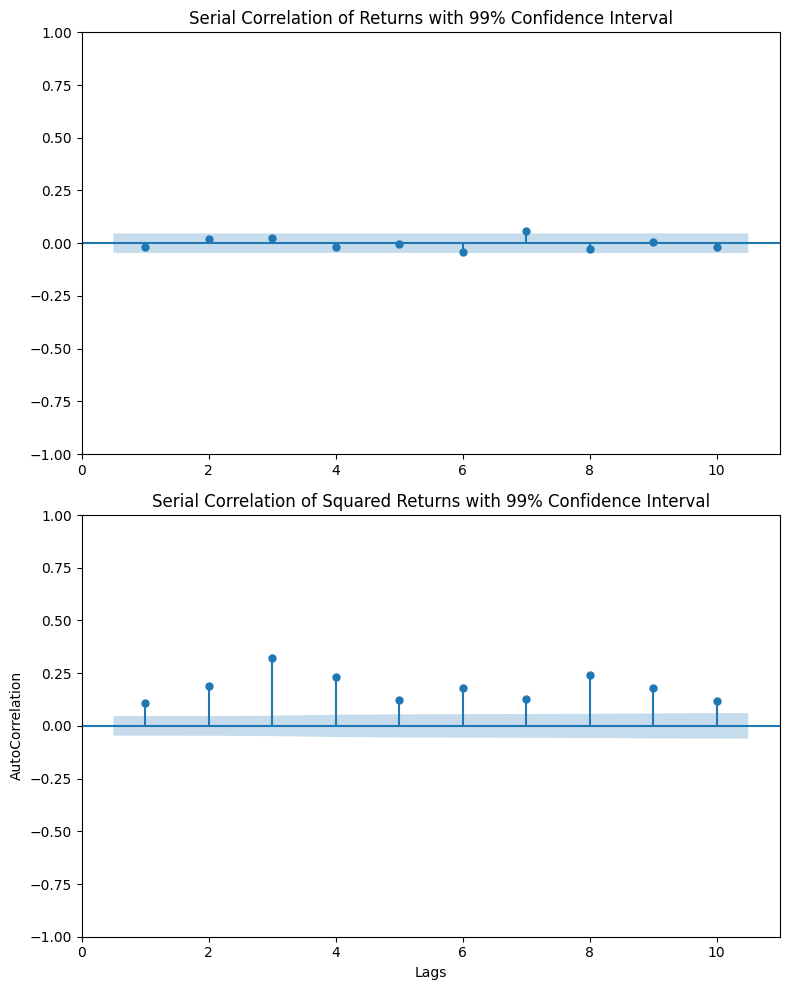

In [635]:
fig, axs = plt.subplots(2,1, figsize =(8,10), sharex = False, sharey = True)
FCHI_acf = sm.acf(FCHI_df['Log Returns'].dropna(), nlags=10)
plot_acf_returns = sgt.plot_acf(FCHI_df['Log Returns'].dropna(), ax=axs[0], lags=10, alpha = 0.01, title='Serial Correlation of Returns with 99% Confidence Interval', zero=False)
plot_acf_squared_returns = sgt.plot_acf(FCHI_df['Squared Returns'].dropna(), lags=10, ax=axs[1], alpha = 0.01, title='Serial Correlation of Squared Returns with 99% Confidence Interval', zero=False)
plt.xlabel('Lags')
plt.ylabel('AutoCorrelation')
plt.tight_layout()

In [711]:
Squared_Returns_ACF = sgt.acf(FCHI_df['Squared Returns'].dropna(), nlags = 11, alpha = 0.05)
ACF_Coefficients_Squared_Returns = pd.DataFrame(Squared_Returns_ACF[0], index = None)
ACF_Coefficients_Squared_Returns.columns = ['Squared Returns']
ACF_Coefficients_Squared_Returns.T.round(2)


,0,1,2,3,4,5,6,7,8,9,10,11
Squared Returns,1.0,0.11,0.19,0.32,0.23,0.12,0.18,0.13,0.24,0.18,0.12,0.15


In [714]:
Returns_ACF = sgt.acf(FCHI_df['Log Returns'].dropna(), nlags = 11, alpha = 0.05)
ACF_Coefficients_Returns = pd.DataFrame(Returns_ACF[0], index = None)
ACF_Coefficients_Returns.columns = ['Returns']
ACF_Coefficients_Returns.T.round(3)

,0,1,2,3,4,5,6,7,8,9,10,11
Returns,1.0,-0.016,0.019,0.024,-0.016,-0.006,-0.04,0.058,-0.03,0.006,-0.018,-0.022


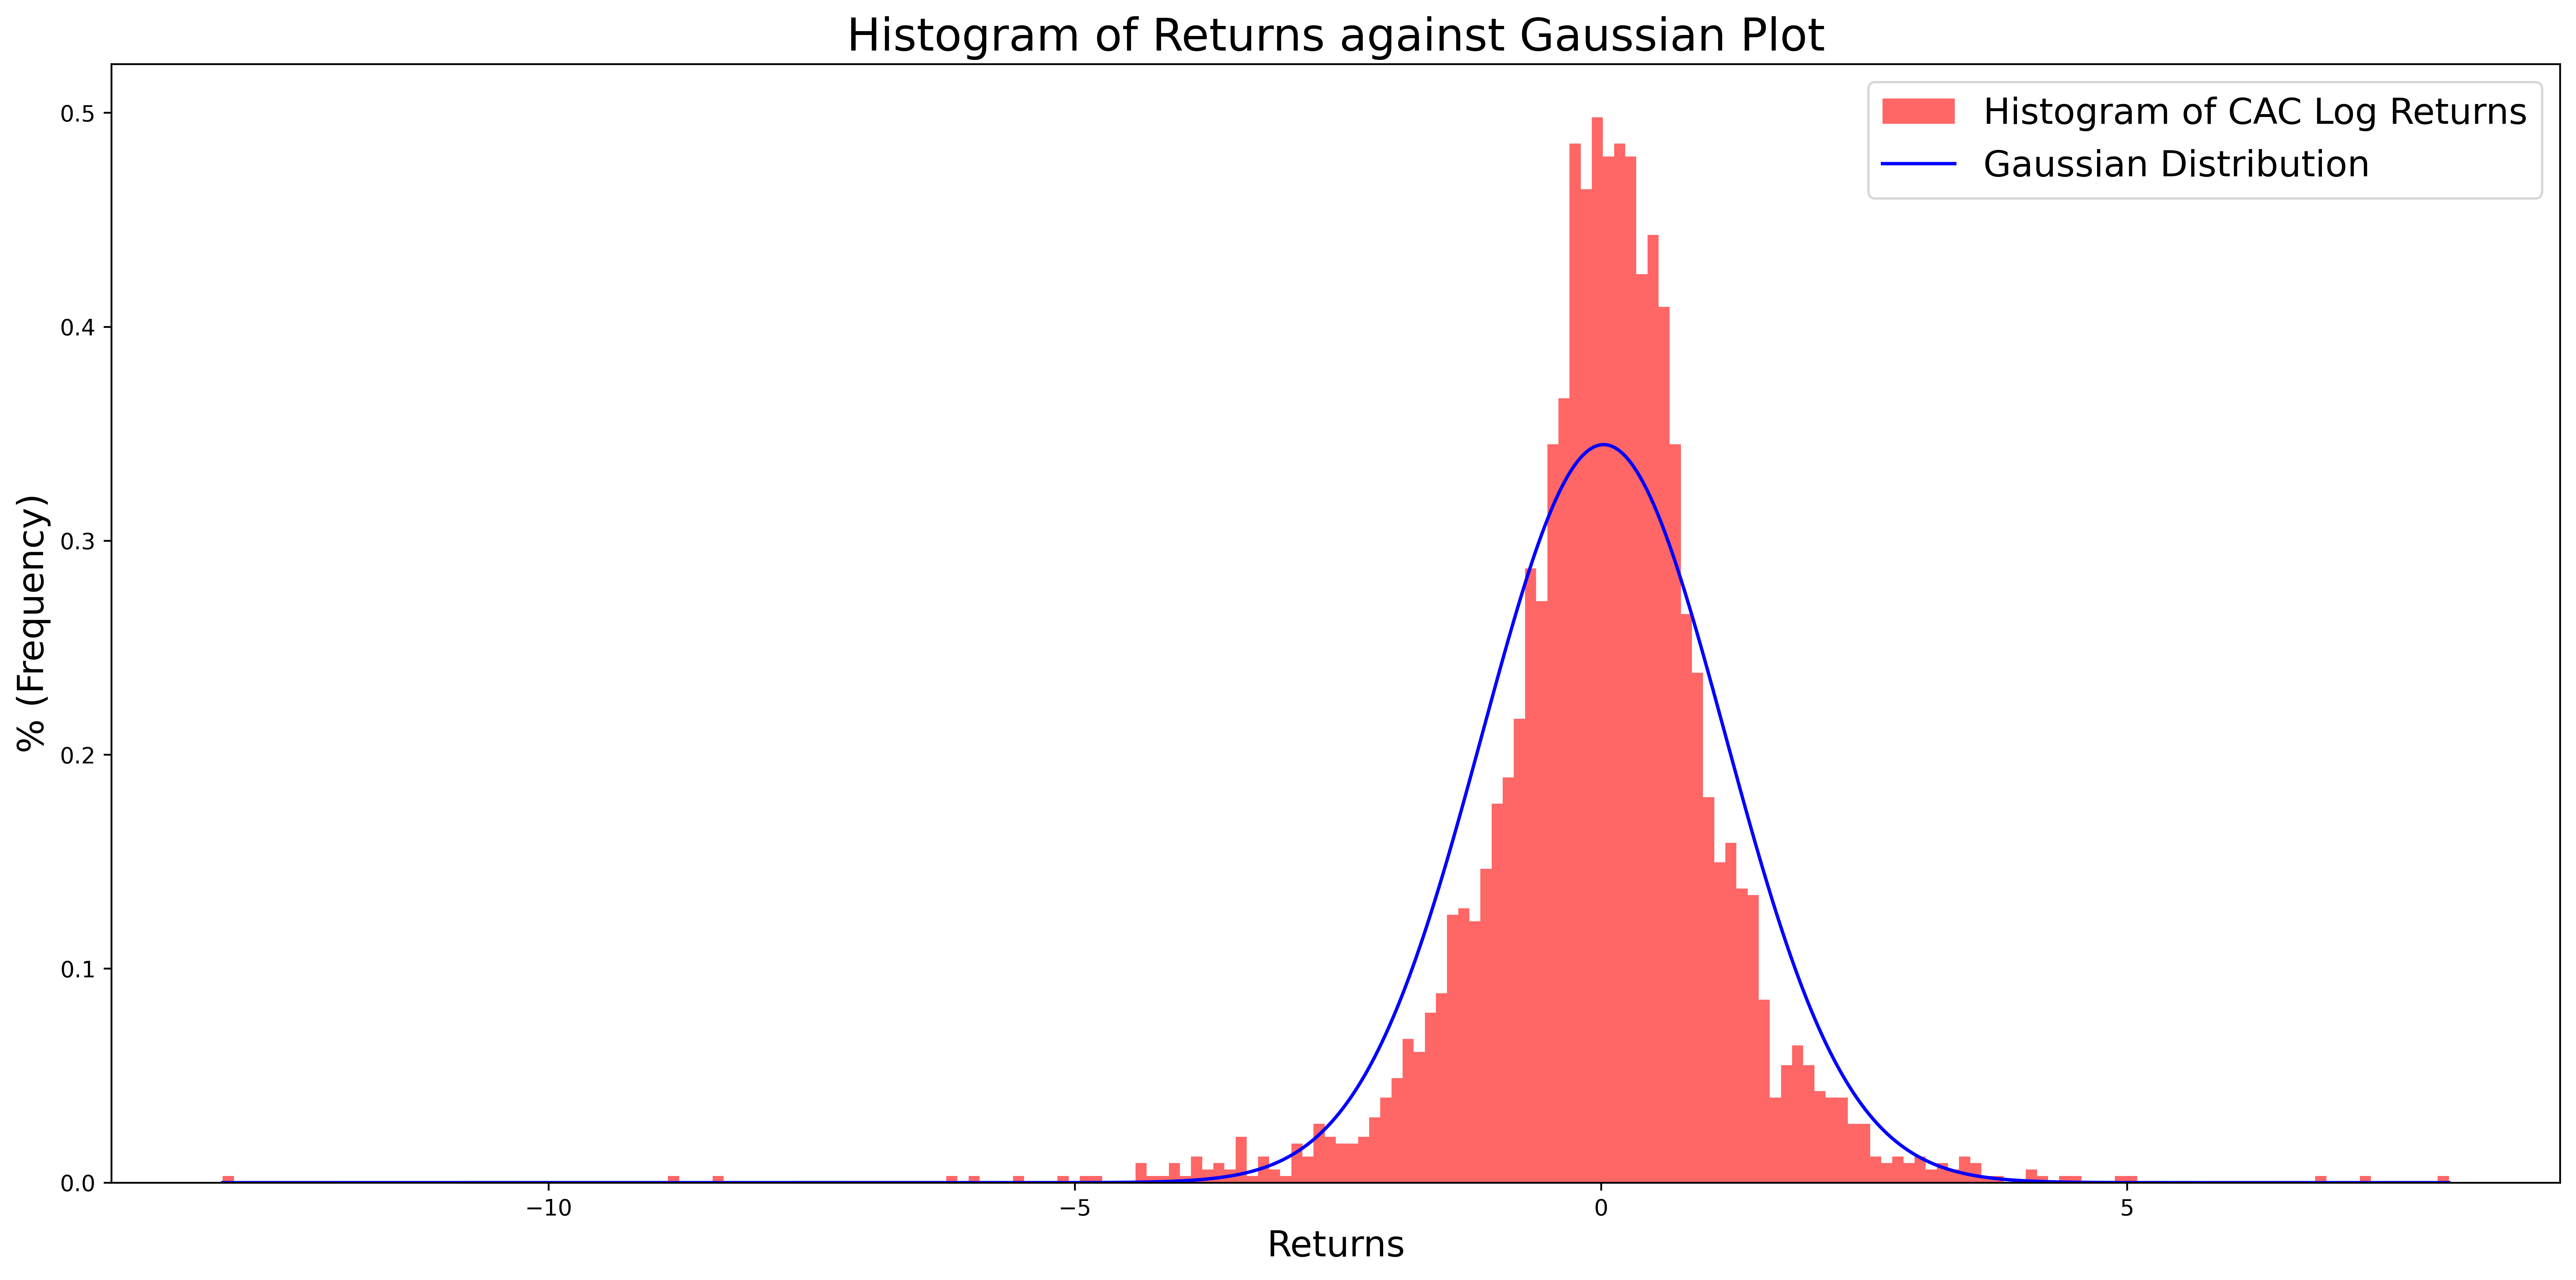

In [215]:
#Setting up Plot
fig, axs = plt.subplots(1, figsize=(16,8), label='Log Returns of CAC', dpi = 500)

#Histogram 
axs.hist(FCHI_df['Log Returns'], bins = 200, color='red', alpha = 0.6, label='Histogram of CAC Log Returns', density = True)

#Gaussian
mean = summary.loc['Mean (%)']['Value']
std = summary.loc['Std (%)']['Value']
x = np.linspace(FCHI_df['Log Returns'].min(), FCHI_df['Log Returns'].max(), len(FCHI_df['Log Returns']))
axs.plot(x, stats.norm.pdf(x, mean, std), color='blue', label='Gaussian Distribution')

#Labels 
plt.title('Histogram of Returns against Gaussian Plot', fontsize=20)
plt.xlabel('Returns', fontsize = 16)
plt.ylabel('% (Frequency)', fontsize = 16)
plt.legend(fontsize=16)
plt.tight_layout()


## Question 2

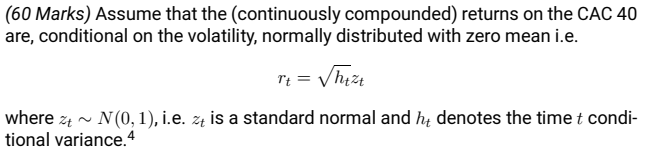

### Moving Average Model

In [187]:
from statsmodels.tsa.arima.model import ARIMA

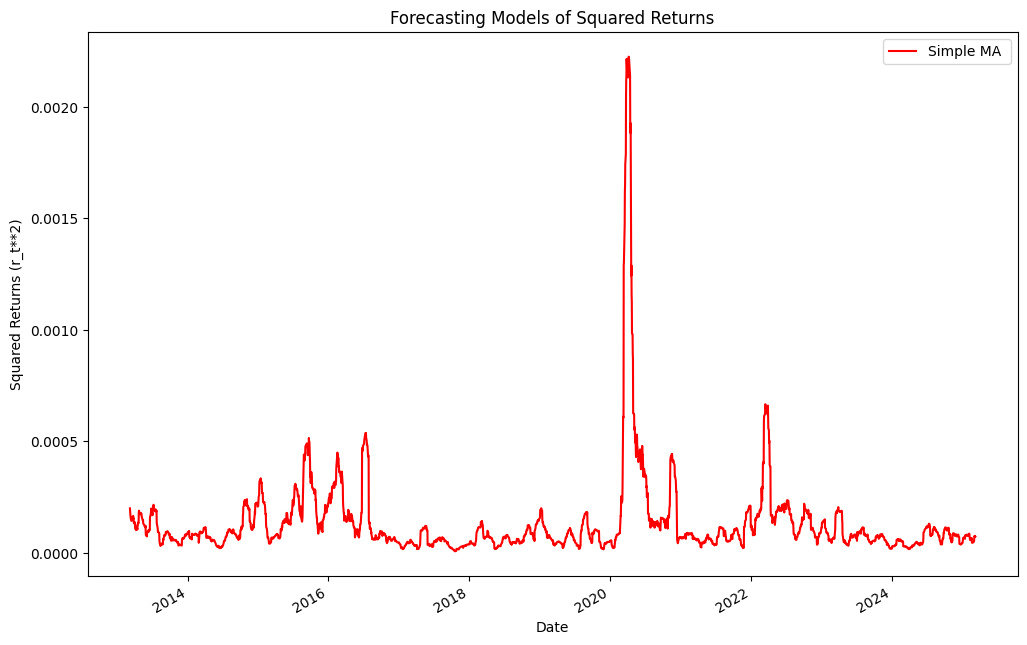

In [310]:
#Simple MA
FCHI_df['Simple MA(25)'] = FCHI_df['Squared Returns'].rolling(window=25).mean() / 10000
#Divide by 100
SMA_Result = FCHI_df['Simple MA(25)'].dropna() 
SMA_Result.plot(label = 'Simple MA ', color = 'red', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()

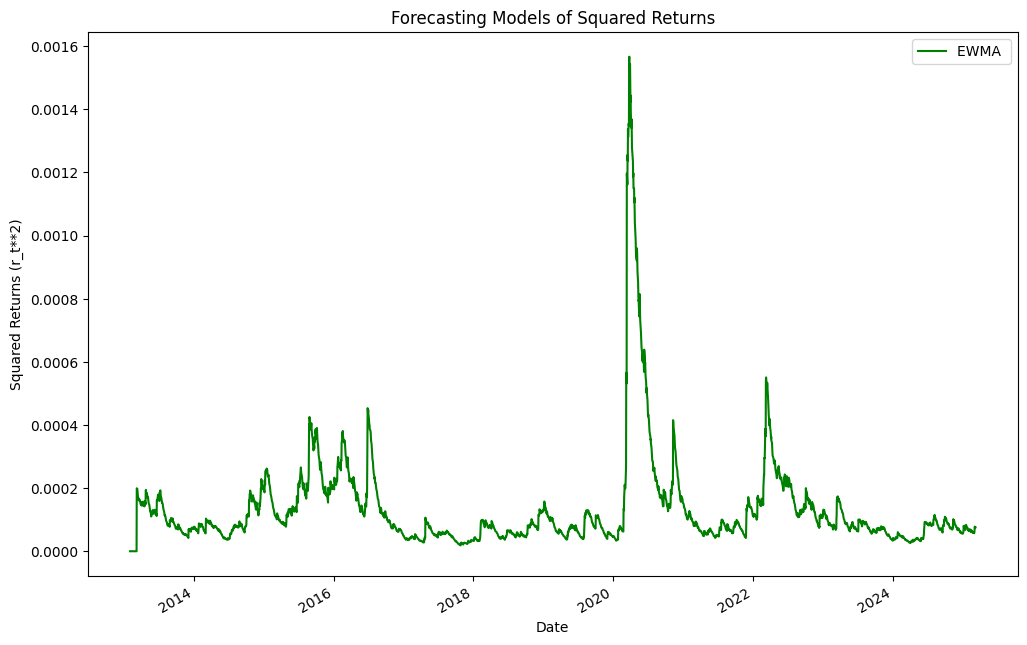

In [305]:
#EWMA - can use Pandas .ewm() if we don't want to set initial value
decay = 0.96
N = 25

#Initialise array to store EWMA 
h_t = np.zeros(len(FCHI_df['Log Returns']))
h_t[N] = FCHI_df['Simple MA(25)'].dropna().iloc[0]  / 100

#Apply EWMA formula from t = N + 1 (26)
for timestep in range(N+1, len(FCHI_df['Log Returns'])):
    h_t[timestep] = (1 - decay) * (FCHI_df['Squared Returns'].iloc[timestep - 1]) / 10000 + (decay) * h_t[timestep -1] 

FCHI_df['EWMA'] = h_t

#EWM Plot
FCHI_df['EWMA'].plot(label = 'EWMA ', color = 'green', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()


In [308]:
#Garch Parameters
w = 3.407e-06 
alpha = 1.078e-01
beta = 0.8719
initial_h = 0.000172836

#GARCH Model
garch_ht = np.zeros(len(FCHI_df['Log Returns']))
garch_ht[0] = initial_h 

for i in range(1, len(garch_ht)):
    garch_ht[i] = w + alpha * FCHI_df['Squared Returns'].iloc[i] / 10000 + beta * garch_ht[i-1]

FCHI_df['GARCH Forecast'] = garch_ht 

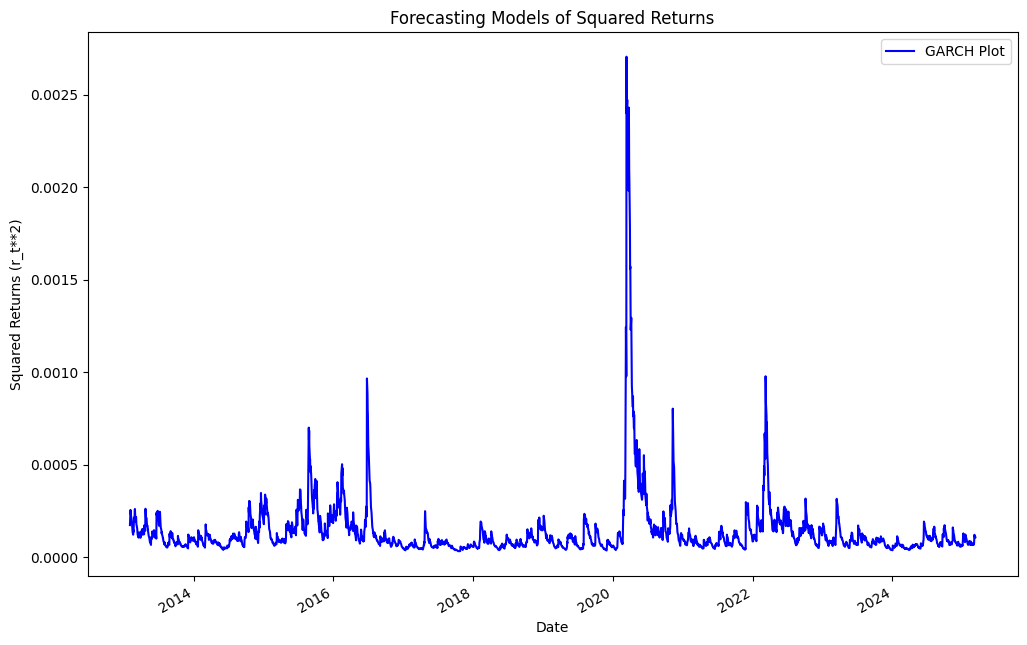

In [633]:
#Plot
plt.figure()
FCHI_df['GARCH Forecast'].plot(label = 'GARCH Plot', color = 'blue', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()


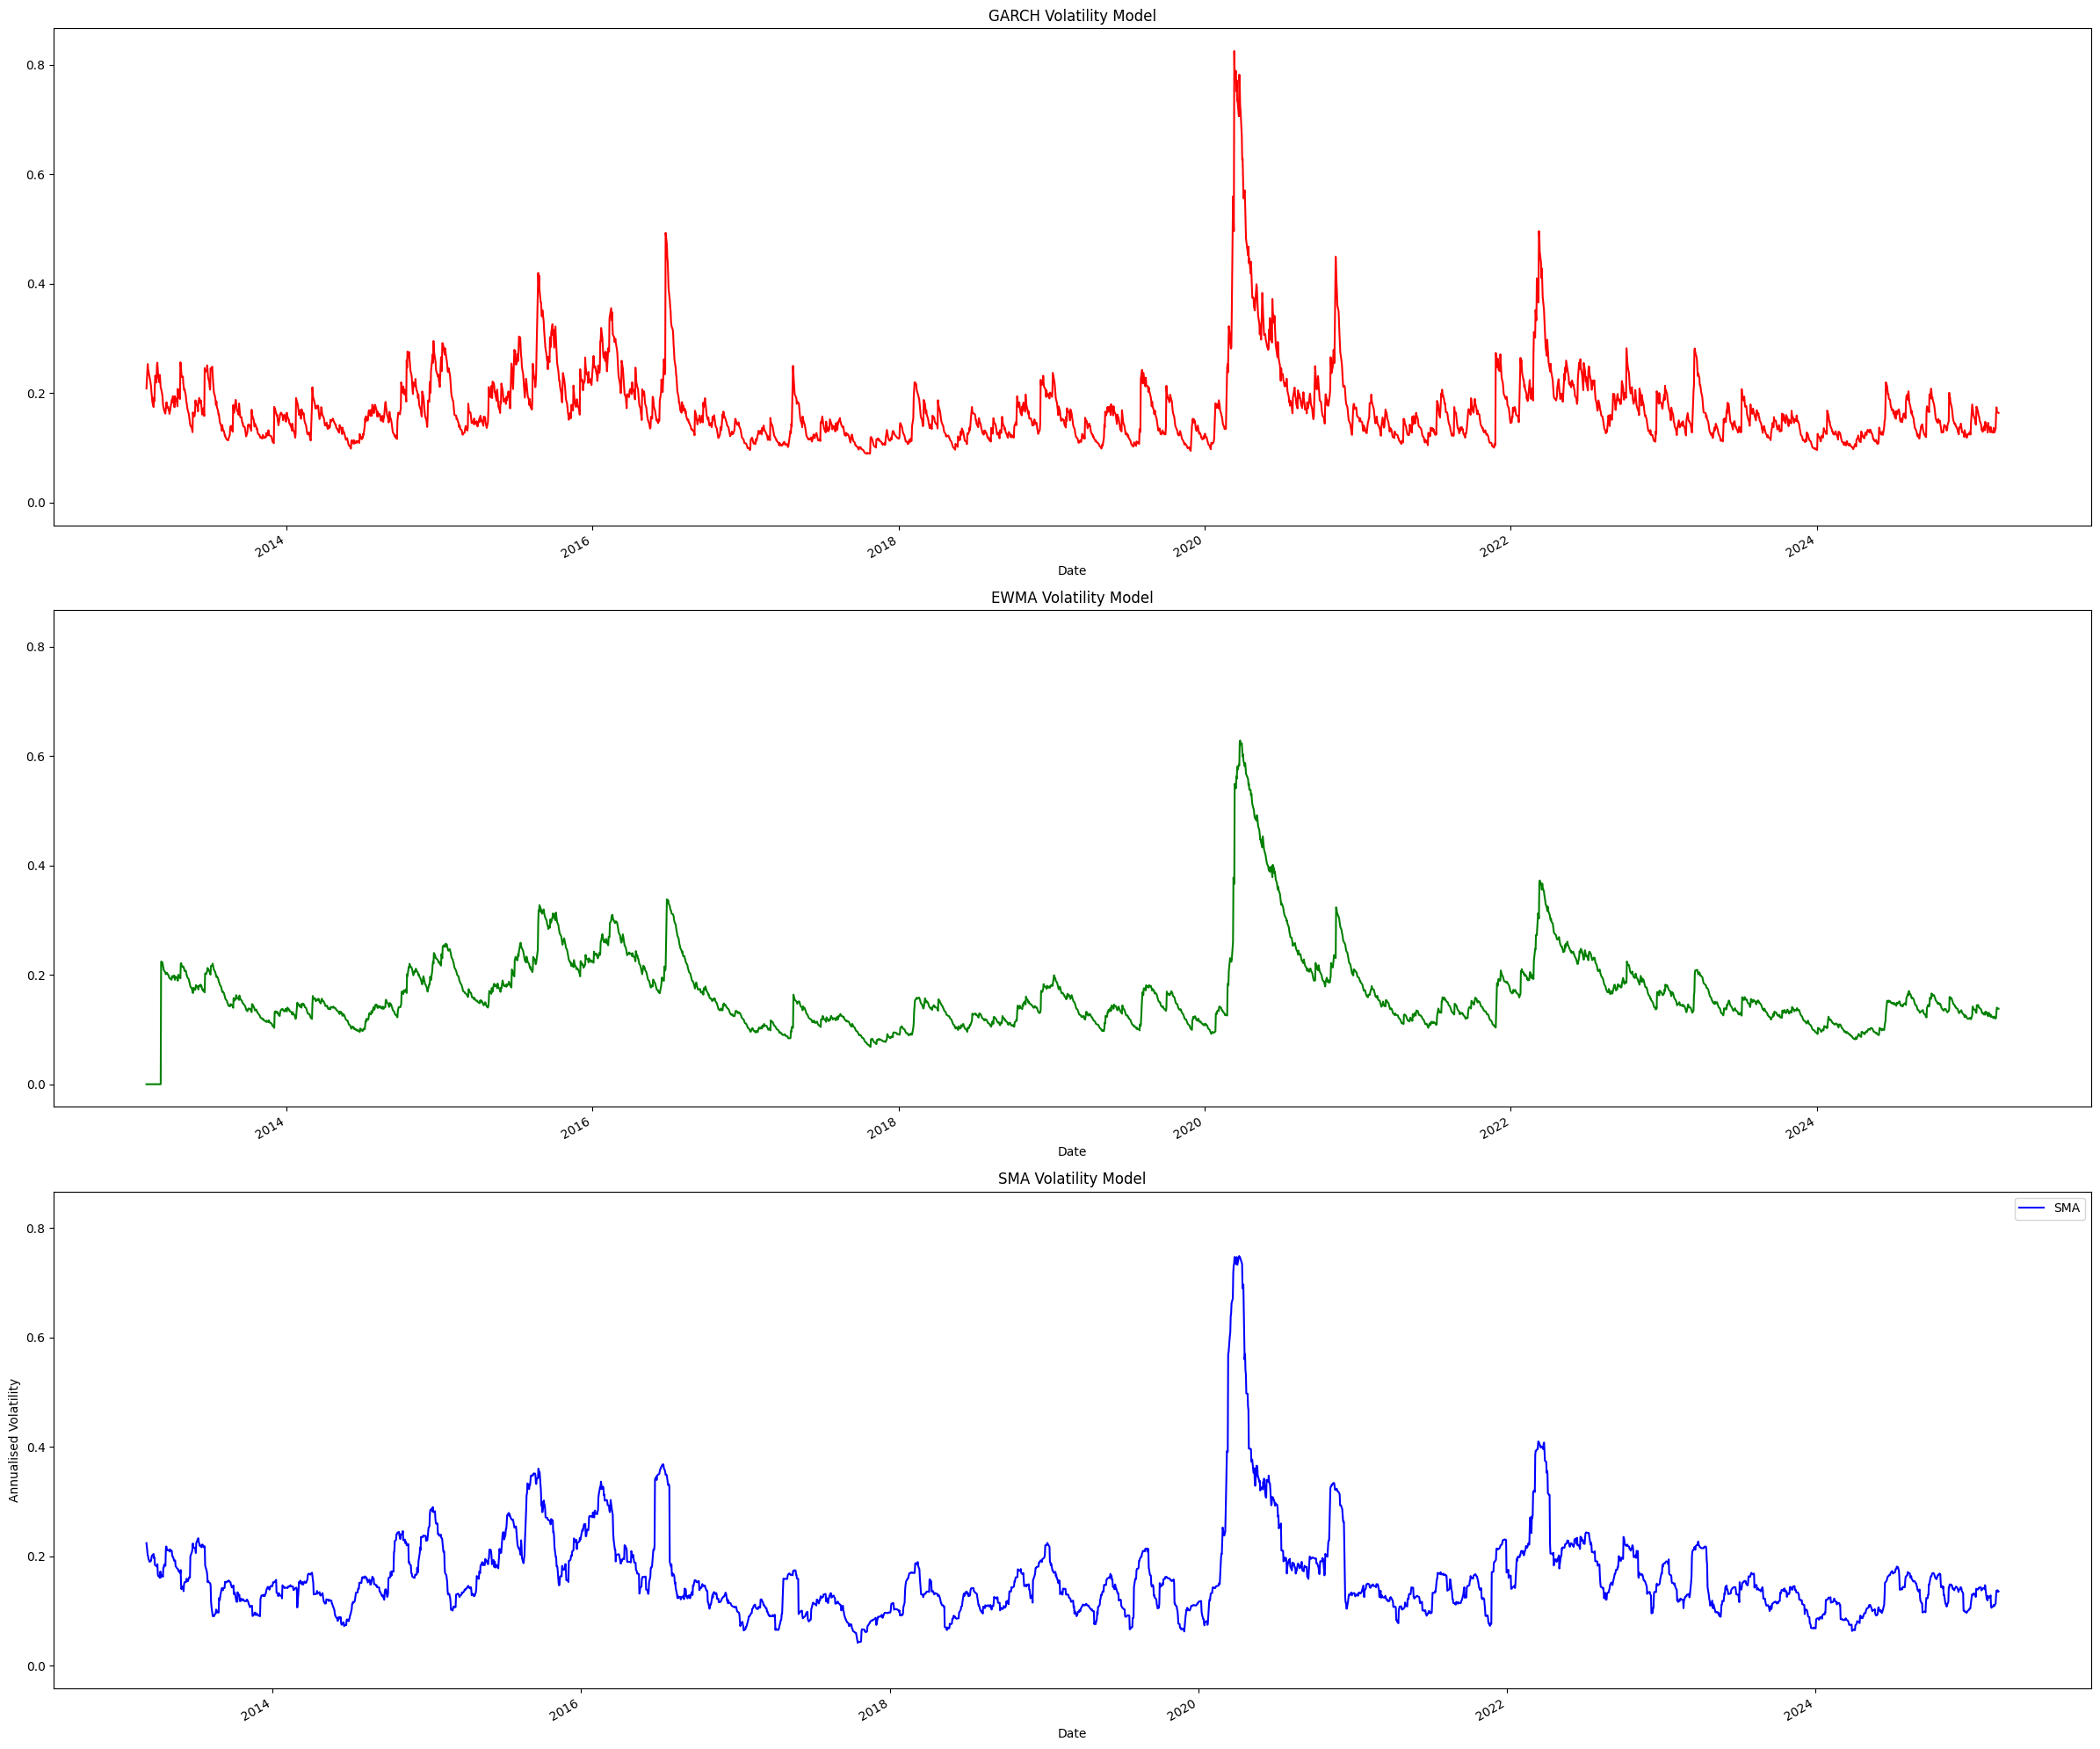

In [311]:
#Turn Variance into Volatility
Volatility_Forecast_df = np.sqrt(FCHI_df.loc[:, ['GARCH Forecast', 'EWMA', 'Simple MA(25)']]) * np.sqrt(252)
#Plot Volatility 
fig, axs = plt.subplots(3,1, figsize=(24, 20), sharey= True, label='Volatility Forecast')
plt.title('Annualised Conditional Volatility Estimates')
Volatility_Forecast_df['GARCH Forecast'].plot(ax=axs[0], label = 'GARCH', color='red', title = 'GARCH Volatility Model')
Volatility_Forecast_df['EWMA'].plot(ax=axs[1], label = 'EWMA', color='green', title = 'EWMA Volatility Model')
Volatility_Forecast_df['Simple MA(25)'].plot(ax=axs[2], label = 'SMA', color='blue', title = 'SMA Volatility Model')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Annualised Volatility')
plt.tight_layout()


In [313]:
Volatility_Forecast_df.dropna().corr()

,GARCH Forecast,EWMA,Simple MA(25)
GARCH Forecast,1.000000,0.876878,0.912337
EWMA,0.876878,1.000000,0.942529
Simple MA(25),0.912337,0.942529,1.000000


## VAR

In [523]:
import matplotlib.dates as mdates
returns = FCHI_df['Log Returns'] / 100
GARCH_Volatility = Volatility_Forecast_df['GARCH Forecast']
EWMA_Volatility = Volatility_Forecast_df['EWMA']
MA_Volatility = Volatility_Forecast_df['Simple MA(25)']

In [ ]:
def daily_VaR(ax, volatility, title, returns = returns, alpha = 0.05):
    #Calculate VaR values (using daily volatility)
    VaR_Daily = pd.Series(stats.norm.ppf(alpha, scale=volatility) / np.sqrt(252))
    VaR_Daily.index = returns.index
    #Plotting
    returns.plot(ax = ax)
    #Formatting Plot
    title_plot = f'VaR using : {title}'
    label = f'Volatility Forecast using :{title}'
    VaR_Daily.plot(ax = ax, title=title_plot, label = label)
    #Violations Array
    violations = returns[returns < VaR_Daily]

    return VaR_Daily, violations



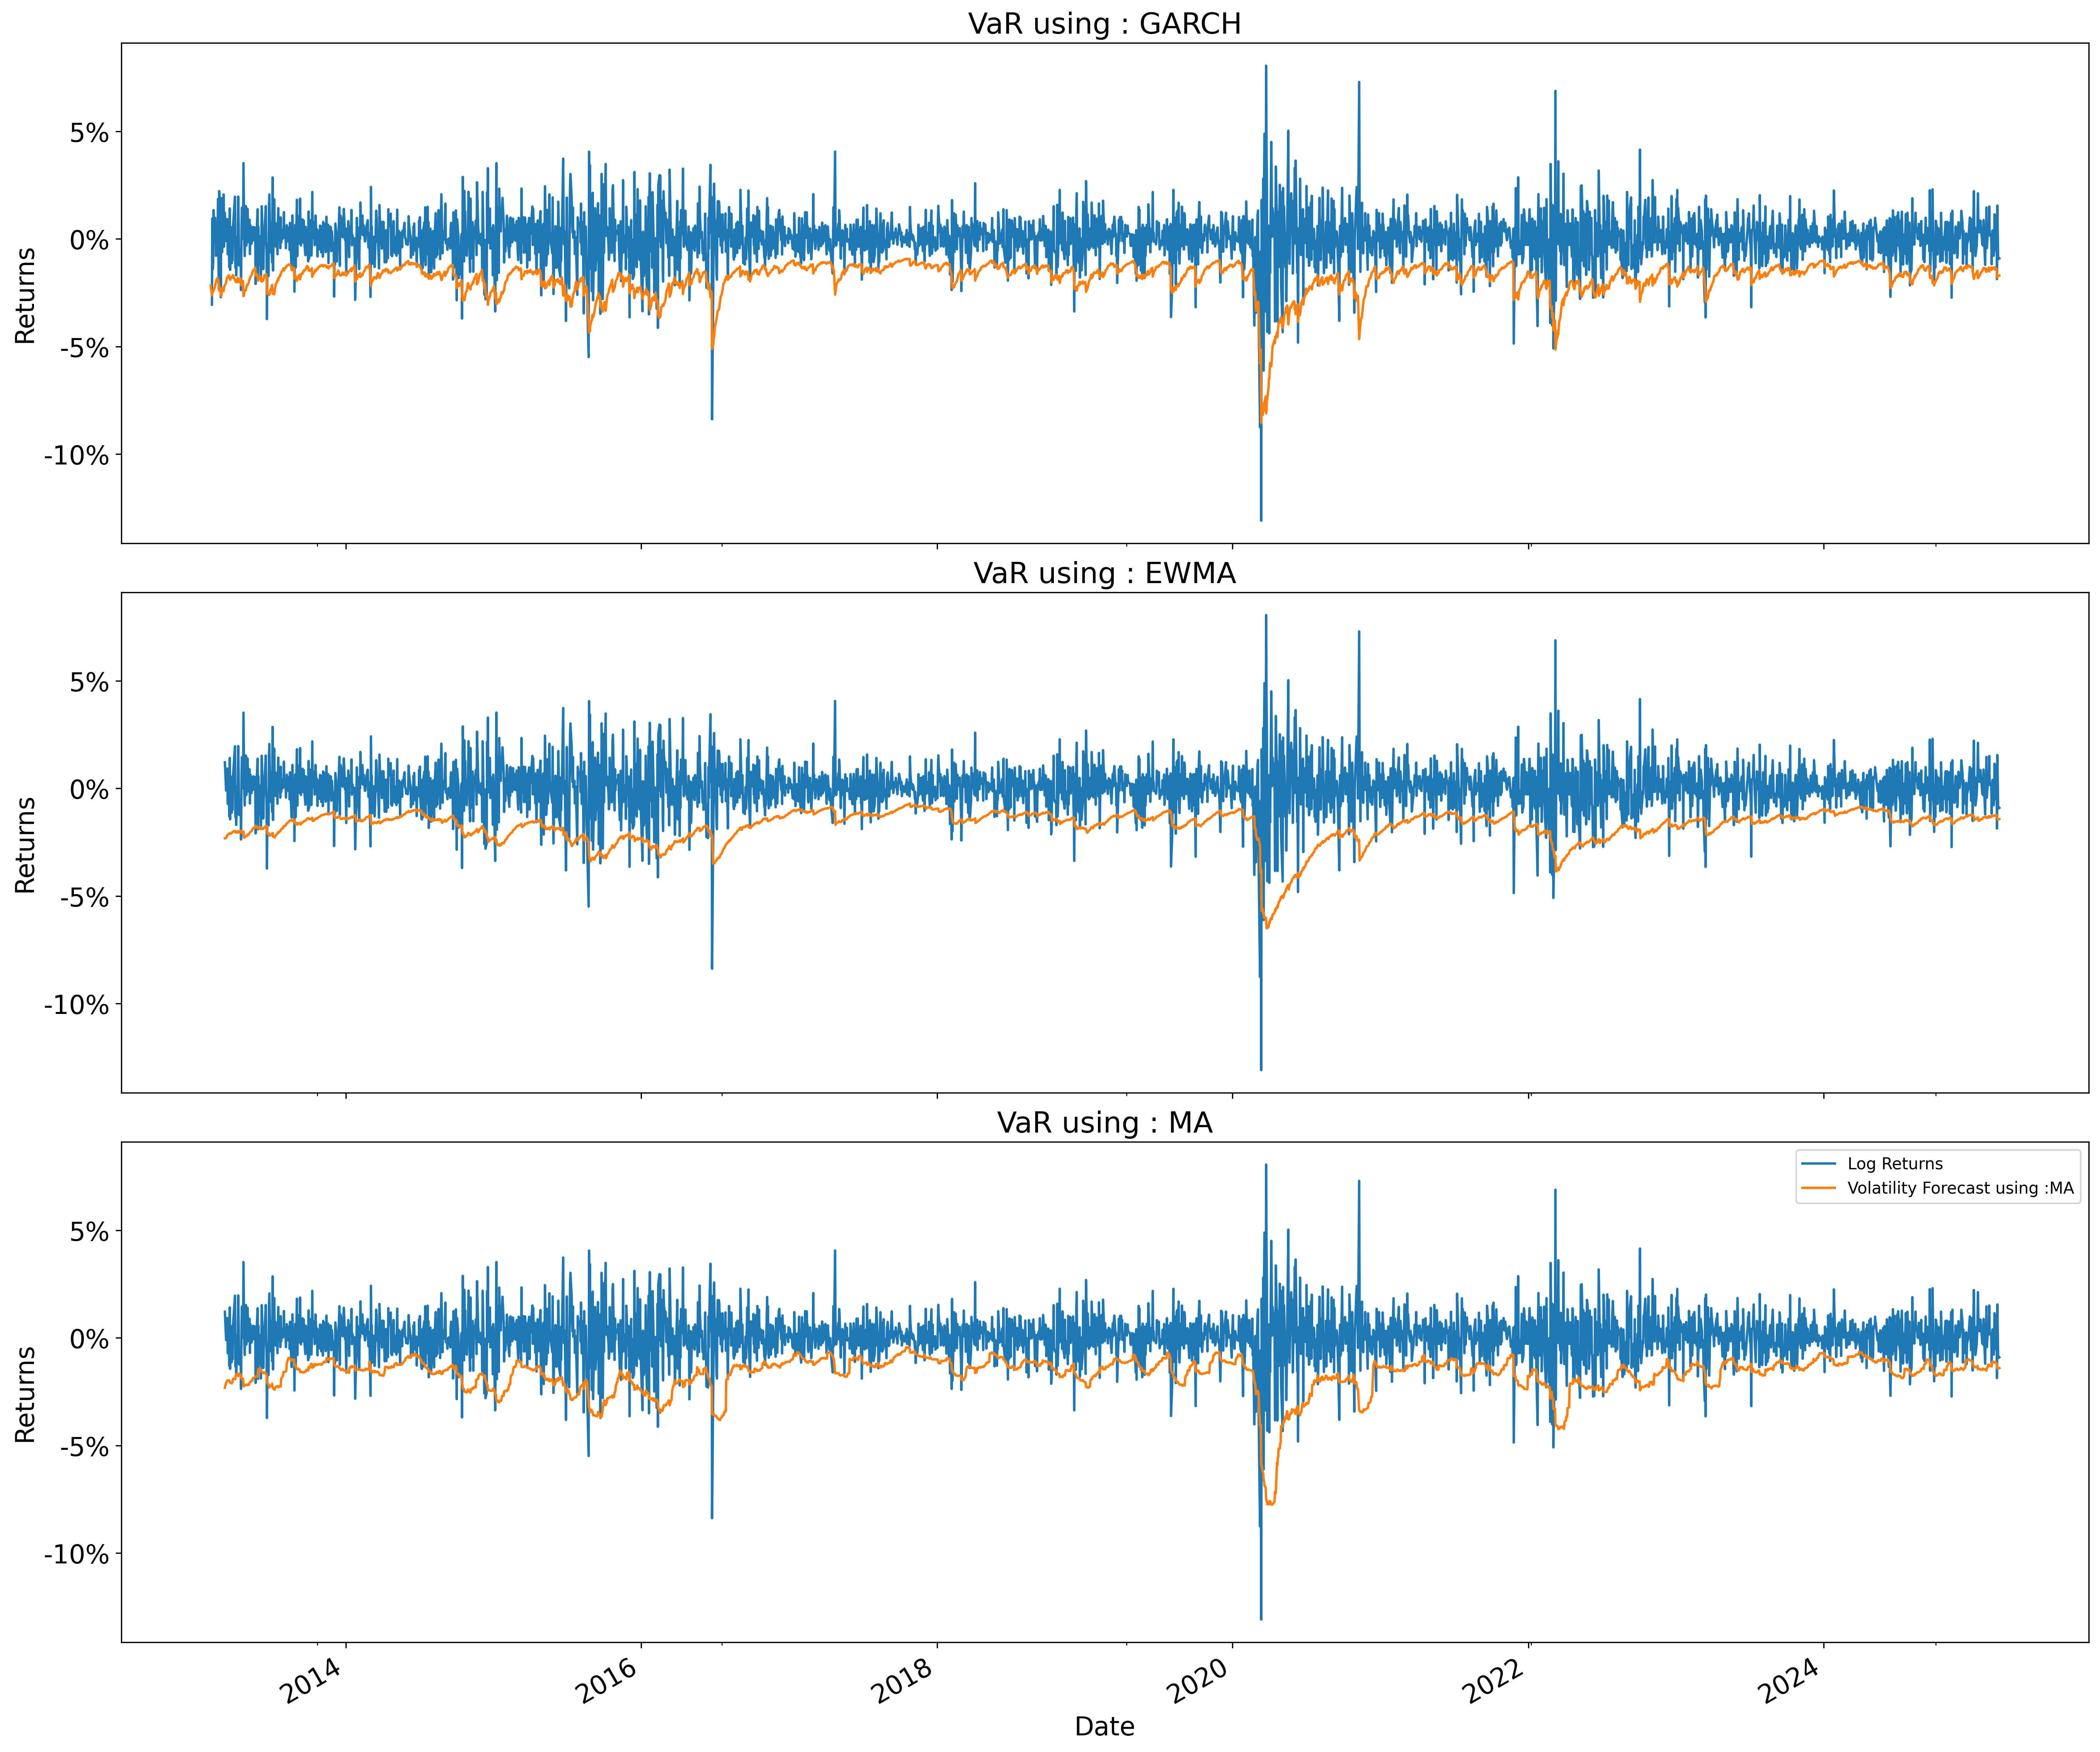

In [601]:
#Plotting
 
fig, axs = plt.subplots(3,1, figsize=(18, 15), dpi = 300, layout='constrained', sharex=True)
ax1, ax2, ax3 = axs.ravel()
VaR_Garch = daily_VaR(ax1, GARCH_Volatility, title= 'GARCH')
VaR_EWMA = daily_VaR(ax2, EWMA_Volatility[25:], returns = returns[25:], title= 'EWMA')
VaR_MA = daily_VaR(ax3, MA_Volatility[25:], returns = returns[25:], title = 'MA')

for ax in axs:
    ax.set_ylabel('Returns')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.set_yticks([-0.10, -0.05, 0,0.05], ['-10%', '-5%', '0%', '5%'])
    ax.xaxis.set_minor_locator
    
plt.legend()

In [598]:
#VaR Violations 
VaR_Violations_Dict_GARCH = {}
VaR_Violations_Dict_EWMA = {}
VaR_Violations_Dict_MA= {}
a = 0
b = 0
c = 0
#Creating the numbers
for i in range(0, len(VaR_Garch[1])):
    c = c + 1 
    VaR_Violations_Dict_GARCH[VaR_Garch[1].index[i]] = c

for i in range(0, len(VaR_EWMA[1])):
    a = a + 1 
    VaR_Violations_Dict_EWMA[VaR_EWMA[1].index[i]] = a

for i in range(0, len(VaR_MA[1])):
    b = b + 1
    VaR_Violations_Dict_MA[VaR_MA[1].index[i]] = b

#Saving it for Plotting
GARCH_Violations = pd.DataFrame(VaR_Violations_Dict_GARCH, index = [0]).T
GARCH_Violations.columns = ['Cumulative Count of VaR Violations']
EWMA_Violations = pd.DataFrame(VaR_Violations_Dict_EWMA, index = [0]).T
EWMA_Violations.columns = ['Cumulative Count of VaR Violations']
MA_Violations = pd.DataFrame(VaR_Violations_Dict_MA, index = [0]).T
MA_Violations.columns = ['Cumulative Count of VaR Violations']

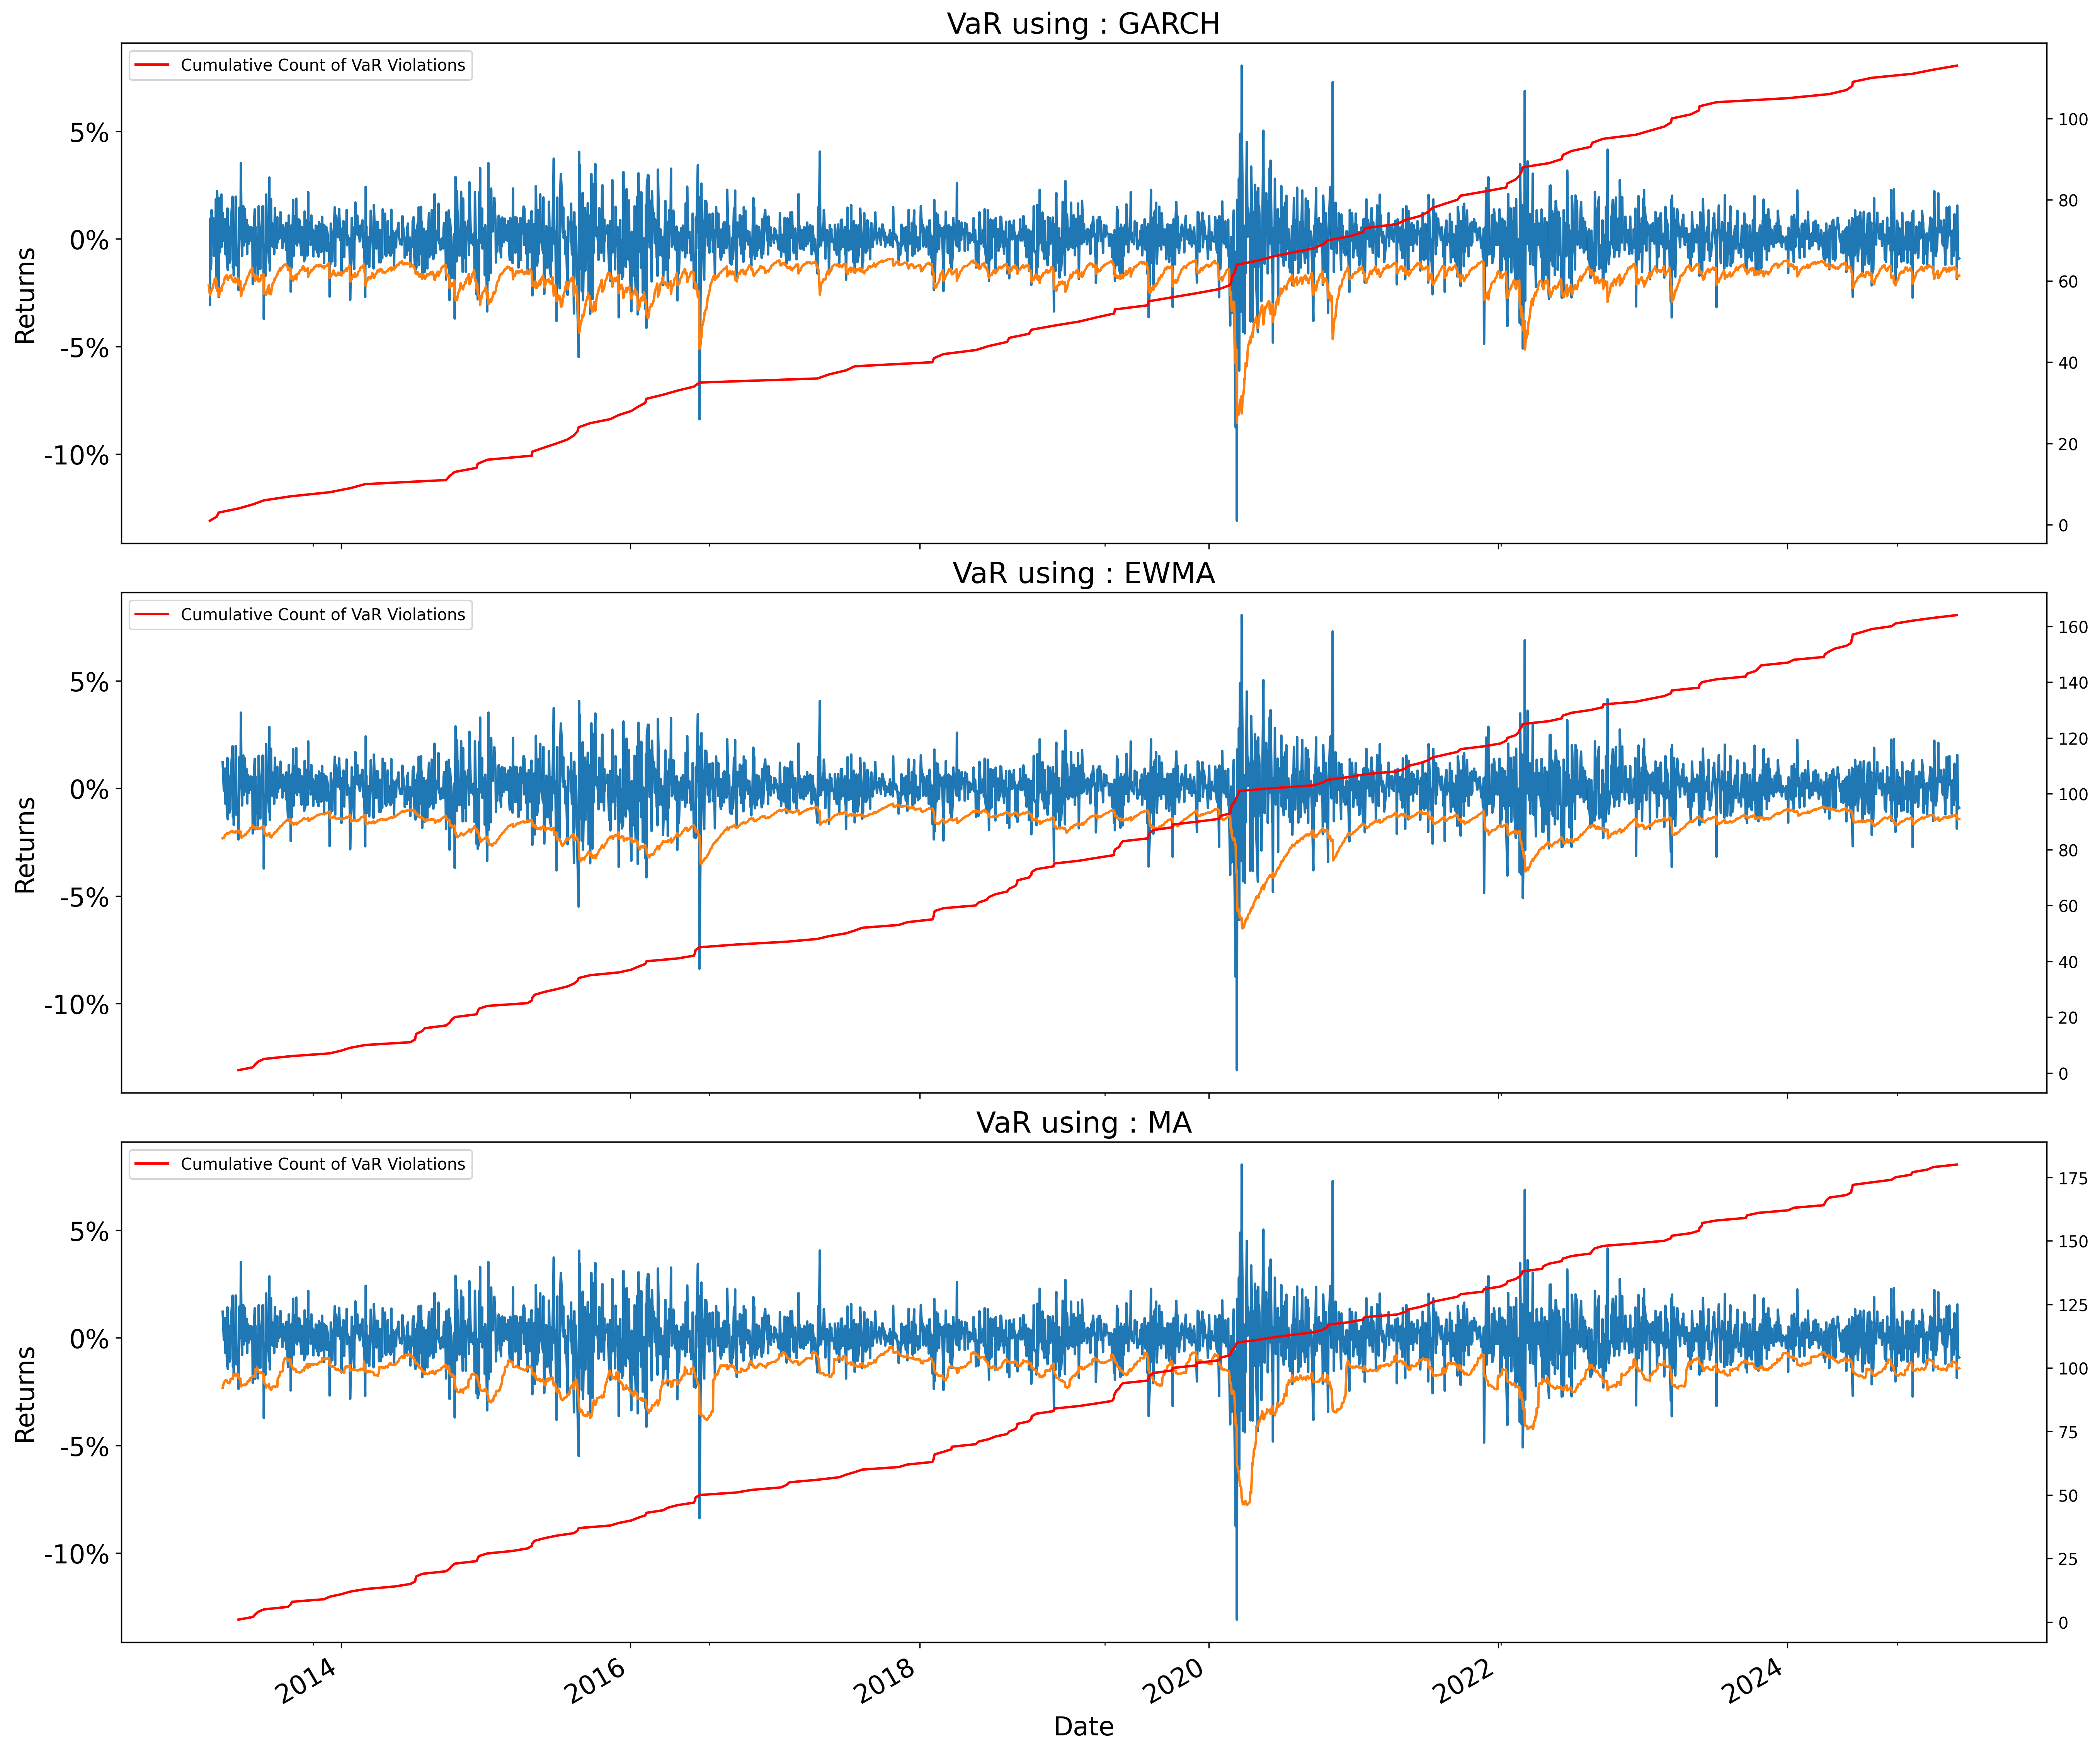

In [600]:
#Plotting
 
fig, axs = plt.subplots(3,1, figsize=(18, 15), dpi = 300, layout='constrained', sharex=True)
ax1, ax2, ax3 = axs.ravel()
VaR_Garch = daily_VaR(ax1, GARCH_Volatility, title= 'GARCH')
VaR_EWMA = daily_VaR(ax2, EWMA_Volatility[25:], returns = returns[25:], title= 'EWMA')
VaR_MA = daily_VaR(ax3, MA_Volatility[25:], returns = returns[25:], title = 'MA')

for ax in axs:
    ax.set_ylabel('Returns')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.set_yticks([-0.10, -0.05, 0,0.05], ['-10%', '-5%', '0%', '5%'])
    ax.xaxis.set_minor_locator

#VaR Violations
ax1_secondary = ax1.twinx()
GARCH_Violations.plot(ax = ax1_secondary, color='red', label='Number of VaR Shocks')
ax2_secondary = ax2.twinx()
EWMA_Violations.plot(ax = ax2_secondary, color='red', label = 'Number of VaR Shocks')
ax3_secondary = ax3.twinx()
MA_Violations.plot(ax = ax3_secondary, color='red', label = 'Number of VaR Shocks')
    
plt.legend()

In [550]:
#2b : Correlations
VaR_df = pd.concat([VaR_Garch[0][25:].T, VaR_EWMA[0].T, VaR_MA[0].T], axis = 1)
VaR_df.columns = ['GARCH', 'EWMA', 'SMA']
VaR_df.corr()

,GARCH,EWMA,SMA
GARCH,1.000000,0.876878,0.912337
EWMA,0.876878,1.000000,0.942529
SMA,0.912337,0.942529,1.000000


In [626]:
#2b: Number of Violations
print('GARCH VaR Violations:', len(VaR_Garch[1]))
print('EWMA VaR Violations:', len(VaR_EWMA[1]))
print('MA VaR Violations:', len(VaR_MA[1]))
print('Expected Violations at 5% interval:', 0.05 * len(FCHI_df['Log Returns'].iloc[25:]))

GARCH VaR Violations: 113
EWMA VaR Violations: 164
MA VaR Violations: 180
Expected Violations at 5% interval: 153.55


In [624]:
axz = plt.subplots(1,1)

GARCH_Violations.plot(ax = axz, color='red', label='GARCH VaR Shocks')
EWMA_Violations.plot(ax = axz, color='blue', label = 'EWMA VaR Shocks')
MA_Violations.plot(ax = axz, color='green', label = 'MA VaR Shocks')
plt.show()

C:\Users\Phillip\AppData\Local\Temp\ipykernel_27024\3566876279.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Question 3 

In [789]:
from scipy.optimize import minimize, fsolve

In [ ]:
def bond_price(ytm, coupon_rate, face=100, maturity=3):
    """
    Returns the present value of all coupon payments plus face value
    under annual compounding, given a yield 'ytm' (decimal).
    """
    # For annual coupons, there are 'maturity' coupon payments
    # plus the face redemption in the final period.
    periods = np.arange(1, maturity+1)
    
    coupon_pv = np.sum([
        (coupon_rate * face) / ((1 + ytm) ** t)
        for t in periods
    ])
    
    # Add the discounted face value at final maturity:
    face_pv = face / ((1 + ytm) ** maturity)
    
    return coupon_pv + face_pv

def yield_to_maturity(price, coupon_rate, face=100, maturity=3, guess=0.05):
    """
    Finds yield-to-maturity (YTM) for a bond with a given market 'price'.
    """
    def objective(ytm):
        return bond_price(ytm, coupon_rate, face, maturity) - price
    
    # Solve for ytm such that the difference is zero
    solution = fsolve(objective, guess)
    
    return solution[0]

In [ ]:
A = yield_to_maturity(106.62, 0.06) * 100
B = yield_to_maturity(123.24, 0.12) * 100

In [803]:
print(f'YTM of Bond A : {A:.4%}')
print(f'YTM of Bond B : {B:.4%}')

YTM of Bond A : 3.6312%
YTM of Bond B : 3.6768%
